In [ ]:
import pandas as pd

df=pd.read_csv("iris (2).csv")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
import matplotlib.pyplot as plt

df=df.drop(['sepal_width', 'sepal_length'], axis=1)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X=df.drop('species', axis=1)
Y=df["species"]

X_scaled=scaler.fit_transform(X)


In [ ]:
from sklearn.cluster import KMeans

wcss=[]
for k in range(1,11):
  kmeans=KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)


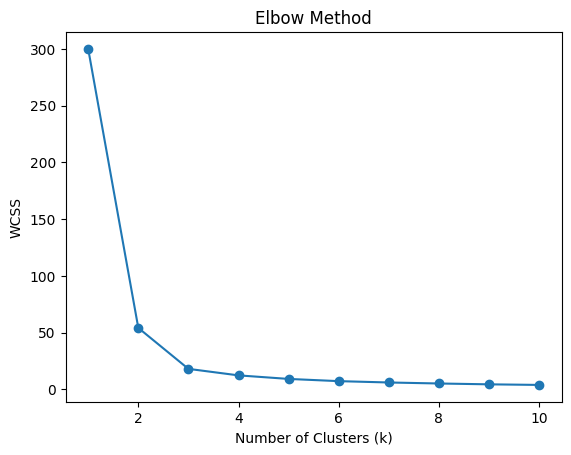

In [ ]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

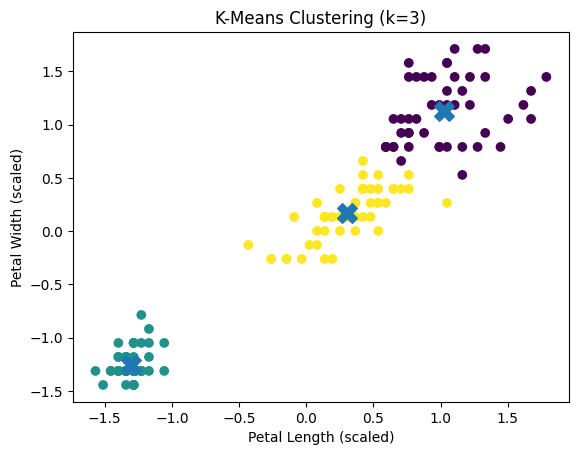

In [ ]:
optimal_k=3

kmeans=KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
Y_means=kmeans.fit_predict(X_scaled)

plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=Y_means)

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=200,marker='X')
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("K-Means Clustering (k=3)")
plt.show()